## <center> Prelims 2024
### <center> Mani Tyagi
#### <center> 200973108

In [48]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


The given system of initial value problem: 
\begin{align}
\frac{dL}{dt} &= f_1(L, X, Y) = -4\alpha X - 4800L, \\
\frac{dX}{dt} &= f_2(L, X, Y) = -5L(Y - 0.01) - 330X, \\
\frac{dY}{dt} &= f_3(L, X, Y) = 5LX - 330(Y - 0.1)
\end{align}

In [49]:
# Define the system of differential equations
def system(t, variables, alpha):
    
    L, X, Y = variables
    dL_dt = -4 * alpha * X - 4800 * L
    dX_dt = -5 * L * (Y - 0.01) - 330 * X
    dY_dt = 5 * L * X - 330 * (Y - 0.1)
    return [dL_dt, dX_dt, dY_dt]

### Part (a)

In [50]:
# Set the initial conditions
initial_conditions = [0.01, 0.01, 0.1]

# Set the parameter alpha
alpha = 0.1

# Set the time points for which to solve the system
t_span = [0, 1]

# Solve the system of IVPs using solve_ivp
solution = solve_ivp(system, t_span, initial_conditions, args=(alpha,), method='RK45')

# Print the solution
print("Time Points (t):\n", solution.t)
print("\nDependent Variables (L, X, Y):")
for i, variable in enumerate(['\nL: ', '\nX: ', '\nY: ']):
    print(f"{variable} {solution.y[i]}")


Time Points (t):
 [0.       0.000196 0.000392 ... 0.998839 0.999602 1.      ]

Dependent Variables (L, X, Y):

L:  [0.01     0.003902 0.001523 ... 0.000001 0.000002 0.      ]

X:  [0.01     0.009373 0.008785 ... 0.       0.       0.      ]

Y:  [0.1 0.1 0.1 ... 0.1 0.1 0.1]


### Part (b)

Fixed points for alpha = 1000000.0:
Fixed Point 1: (0, 0, 0.1)
Fixed Point 2: (24.372115, -0.029247, 0.089200)
Fixed Point 3: (-24.372115, 0.029247, 0.089200)



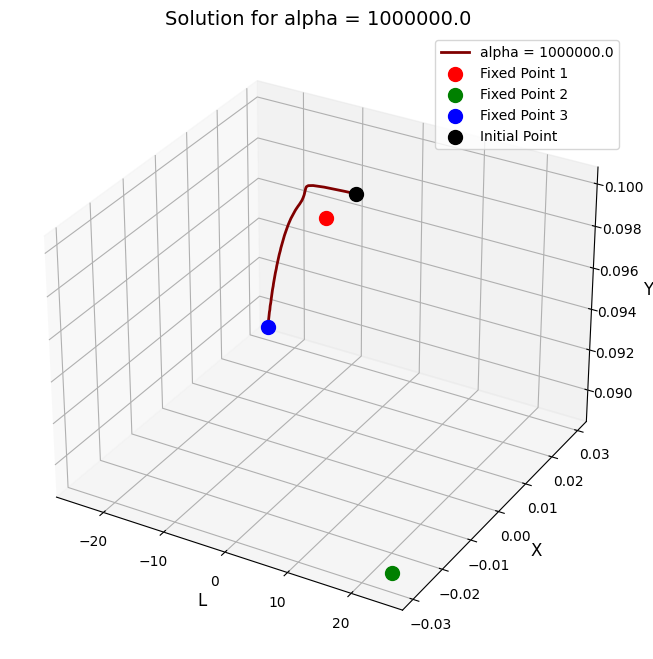

Fixed points for alpha = 3000000.0:
Fixed Point 1: (0, 0, 0.1)
Fixed Point 2: (102.440226, -0.040976, 0.036400)
Fixed Point 3: (-102.440226, 0.040976, 0.036400)



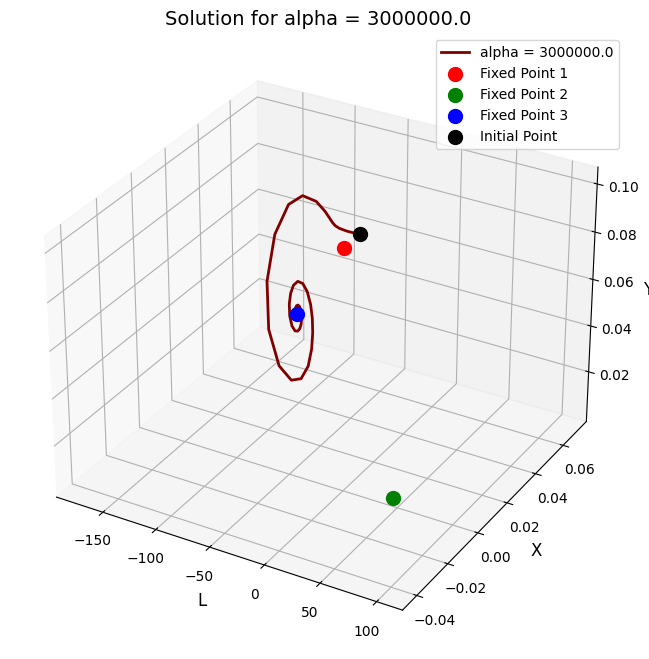

Fixed points for alpha = 20000000.0:
Fixed Point 1: (0, 0, 0.1)
Fixed Point 2: (307.642650, -0.018459, 0.013960)
Fixed Point 3: (-307.642650, 0.018459, 0.013960)



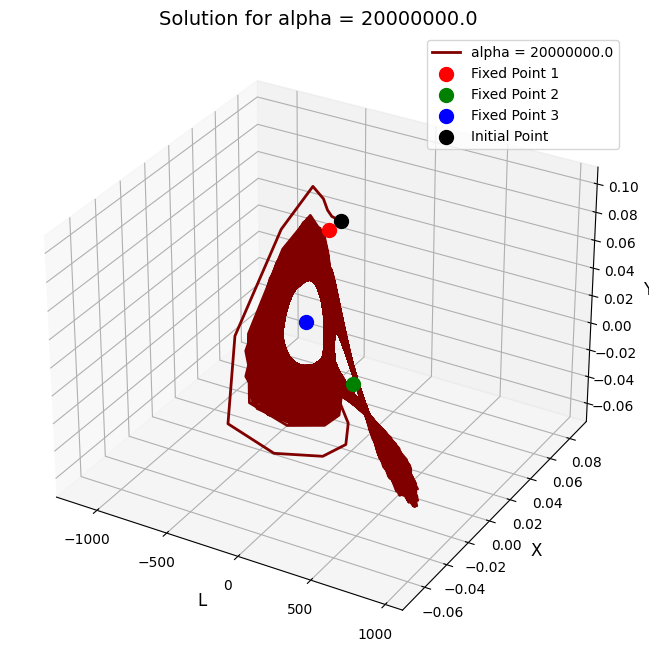

In [51]:
# Set the initial conditions
initial_conditions = [0.01, 0.01, 0.1]

# Set the values of alpha
alpha_values = [1e6, 3e6, 2e7]

# Set the time points for which to solve the system
t_span = [0, 1]


# Loop over alpha values
for alpha in (alpha_values):
    # Solve the system of IVPs using solve_ivp
    solution = solve_ivp(system, t_span, initial_conditions, args=(alpha,), method='RK45')

    # Create a new figure for each alpha value
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    # three fixed points
    L1 = 0
    X1 = 0
    Y1 = 0.1
    
    print(f"Fixed points for alpha = {alpha}:")
    
    # Calculate fixed points
    L_tilde = 66 * np.sqrt(alpha / 880000 - 1)
    L2 = L_tilde
    L3 = -L_tilde
    X2 = -(1200 / alpha) * L_tilde
    X3 = (1200 / alpha) * L_tilde
    Y2 = 0.1 - 200 / (11 * alpha) * L_tilde ** 2
    Y3 = 0.1 - 200 / (11 * alpha) * L_tilde ** 2
    
    # Print fixed points
    print(f"Fixed Point 1: (0, 0, 0.1)")
    print(f"Fixed Point 2: ({L2:.6f}, {X2:.6f}, {Y2:.6f})")
    print(f"Fixed Point 3: ({L3:.6f}, {X3:.6f}, {Y3:.6f})")
    print()
    
    # Plot the solution in three-dimensional space
    ax.plot(solution.y[0], solution.y[1], solution.y[2], label=f'alpha = {alpha}', color='maroon', linewidth=2)
    ax.set_xlabel('L', fontsize=12)
    ax.set_ylabel('X', fontsize=12)
    ax.set_zlabel('Y', fontsize=12)
    ax.set_title(f'Solution for alpha = {alpha}', fontsize=14)
    
    # Grid settings
    ax.grid(True, which='both', linestyle=':', linewidth=0.5, color='gray', alpha=0.6)
    
    # Scatter plot for fixed points and initial points
    fixed_points = [(0, 0, 0.1), (L2, X2, Y2), (L3, X3, Y3)]
    colors = ['r', 'g', 'b']
    for i, (L, X, Y) in enumerate(fixed_points):
        ax.scatter(L, X, Y, color=colors[i], marker='o', s=100, label=f'Fixed Point {i+1}')

    ax.scatter(initial_conditions[0], initial_conditions[1], initial_conditions[2], color='black', marker='o', s=100, label='Initial Point')
    
    # Add legend
    ax.legend(fontsize=10)

    # Show plot
    plt.show()

### Part (c)

The Jacobian matrix \( J \) is given by:

$$
J =
\begin{bmatrix}
\frac{\partial f_1}{\partial L} & \frac{\partial f_1}{\partial X} & \frac{\partial f_1}{\partial Y} \\
\frac{\partial f_2}{\partial L} & \frac{\partial f_2}{\partial X} & \frac{\partial f_2}{\partial Y} \\
\frac{\partial f_3}{\partial L} & \frac{\partial f_3}{\partial X} & \frac{\partial f_3}{\partial Y}
\end{bmatrix}
$$

Calculating the partial derivatives:
\begin{align*}
\frac{\partial f_1}{\partial L} = -4800,  \quad \quad 
\frac{\partial f_1}{\partial X} = -4\alpha,  \quad \quad
\frac{\partial f_1}{\partial Y} = 0 \\
\\
\frac{\partial f_2}{\partial L} = -5(Y - 0.01), \quad
\frac{\partial f_2}{\partial X} = -330, \quad
\frac{\partial f_2}{\partial Y} = -5L \\
\\
\frac{\partial f_3}{\partial L} = 5X, \quad \quad
\frac{\partial f_3}{\partial X} = 5L, \quad 
\frac{\partial f_3}{\partial Y} = -330 \\
\end{align*}
<br>
Hence, the Jacobian matrix is
$$
J =\begin{bmatrix}
-4800 & -4\alpha & 0 \\
-5(Y - 0.01) & -330 & -5L \\
5X & 5L & -330
\end{bmatrix}
$$

### Part (d)

In [52]:
# Define the Jacobian matrix
def jacobian(L, X, Y, alpha):
    J = np.array([
        [-4800, -4*alpha, 0],
        [-5*(Y - 0.01), -330, -5*L],
        [5*X, 5*L, -330]
    ])
    return J

# Fixed points
fixed_points = [(L1, X1, Y1), (L2, X2, Y2), (L3, X3, Y3)]

# Values of alpha
alpha_values = [1e6, 3e6, 2e7]

# Loop over alpha values
for alpha in alpha_values:
    print("-"*60)
    print(f"Eigenvalues for alpha = {alpha}:")
    print("-"*60)
    
    for i, point in enumerate(fixed_points):
        L, X, Y = point
        
        # Compute the Jacobian matrix
        J = jacobian(L, X, Y, alpha)
        
        # Compute eigenvalues
        eigenvalues = np.linalg.eigvals(J)
        print(f"Fixed point {i+1}: {eigenvalues} ")
    
    print("-"*60)
    print("\n")


------------------------------------------------------------
Eigenvalues for alpha = 1000000.0:
------------------------------------------------------------
Fixed point 1: [-5171.765237    41.765237  -330.      ] 
Fixed point 2: [-4840.73096   +0.j        -309.63452+1571.690698j
  -309.63452-1571.690698j] 
Fixed point 3: [-4840.73096   +0.j        -309.63452+1571.690698j
  -309.63452-1571.690698j] 
------------------------------------------------------------


------------------------------------------------------------
Eigenvalues for alpha = 3000000.0:
------------------------------------------------------------
Fixed point 1: [-5789.162682   659.162682  -330.      ] 
Fixed point 2: [-4919.261959   +0.j        -270.36902 +1634.707472j
  -270.36902 -1634.707472j] 
Fixed point 3: [-4919.261959   +0.j        -270.36902 +1634.707472j
  -270.36902 -1634.707472j] 
------------------------------------------------------------


------------------------------------------------------------
Eig